# Series macroeconómicas de Chile: descripción y descomposición

**Pregunta.** ¿Qué patrones tienen la inflación, la actividad, la TPM y el dólar en Chile, y qué transformaciones necesitan antes de modelarlas?

**Datos.** Series mensuales y diarias del Banco Central de Chile publicadas por mindicador.cl:

| Serie | Frecuencia | Desde | Unidad |
|---|---|---|---|
| IPC | mensual | 1995 | variación mensual, % |
| IMACEC | mensual | 1997 | variación anual, % |
| TPM | diaria | 2001 | %, nivel |
| Dólar observado | diaria | 2000 | pesos por dólar |

**Resultado principal.** La inflación mensual tiene una estacionalidad moderada, con alzas en marzo, julio, septiembre y octubre. Los niveles del IPC y del dólar tienen raíz unitaria y deben modelarse en variaciones. La inflación, el IMACEC y la TPM se comportan como series estacionarias en esta muestra. La autocorrelación de la inflación mensual sugiere un modelo con componente estacional de 12 meses, que se estima en el notebook 02.

## 1. Configuración y datos

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

from dsaplicado import datos, series as st
from dsaplicado.graficos import COLORES, NEUTRO, TINTA_SECUNDARIA, TINTA_TENUE, aplicar_estilo

aplicar_estilo()
pd.set_option("display.float_format", "{:.3f}".format)

RAIZ = datos.raiz_repositorio()
FIGURAS = RAIZ / "03_series_de_tiempo" / "figuras"
FIGURAS.mkdir(exist_ok=True)

def cargar(codigo, anios):
    return datos.cargar_indicador(RAIZ / "datos" / f"{codigo}_historico.csv", codigo, anios)

ipc = cargar("ipc", range(1995, 2027))
imacec = cargar("imacec", range(1997, 2027))
tpm = cargar("tpm", range(2001, 2027))
dolar = cargar("dolar", range(2000, 2027))

# Las series mensuales se fechan el primer día de cada mes.
for serie in (ipc, imacec):
    serie.index = serie.index.to_period("M").to_timestamp()

for nombre, serie in {"IPC": ipc, "IMACEC": imacec, "TPM": tpm, "Dólar": dolar}.items():
    print(f"{nombre:7s} {len(serie):5d} datos, de {serie.index.min():%m-%Y} a {serie.index.max():%m-%Y}")

IPC       372 datos, de 01-1995 a 12-2025
IMACEC    355 datos, de 01-1997 a 07-2026
TPM      6234 datos, de 08-2001 a 09-2026
Dólar    6661 datos, de 01-2000 a 09-2026


### Control de calidad

- **IPC.** La fuente publica el IPC hasta diciembre de 2025. Los resultados de inflación cubren hasta esa fecha.
- **TPM.** Igual que en el bloque de finanzas, hay un 0% erróneo en julio de 2020 que se reemplaza por el valor anterior.
- **Validación del IPC.** La inflación de diciembre de cada año, reconstruida desde las variaciones mensuales, coincide con las cifras oficiales conocidas: 12,8% en 2022 y 7,8% en 2007. La diferencia de una décima en algunos años viene del redondeo de las variaciones mensuales publicadas.

In [2]:
tpm = tpm.mask(tpm < 0.25).ffill()

indice_ipc = st.indice_desde_variaciones(ipc)
inflacion_anual = st.variacion_anual(indice_ipc).dropna()
diciembre = inflacion_anual[inflacion_anual.index.month == 12]
print("Inflación a diciembre, años seleccionados:")
print(diciembre[diciembre.index.year.isin([2007, 2008, 2009, 2021, 2022, 2023, 2024, 2025])].round(1).to_string())

Inflación a diciembre, años seleccionados:
fecha
2007-12-01    7.800
2008-12-01    7.200
2009-12-01   -1.600
2021-12-01    7.300
2022-12-01   12.900
2023-12-01    3.900
2024-12-01    4.600
2025-12-01    3.400


## 2. Inflación anual y meta del Banco Central

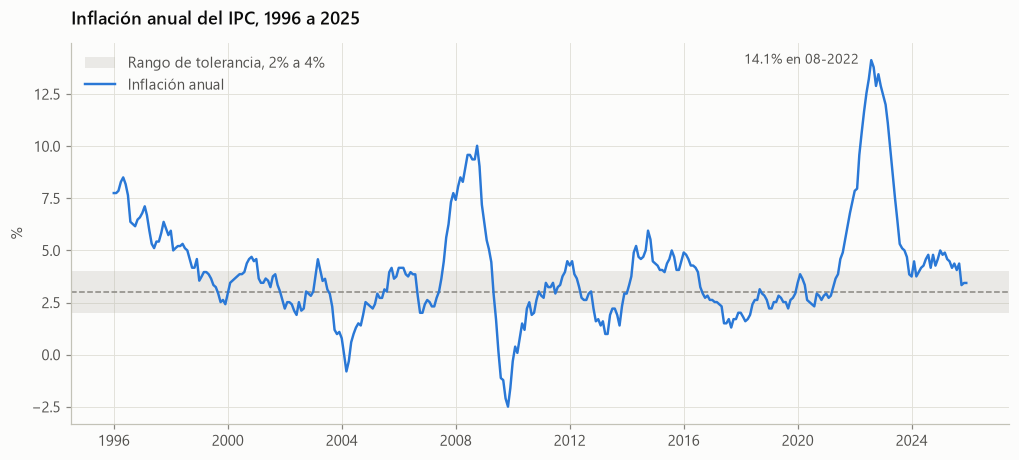

Desde 2002, la inflación estuvo dentro del rango de 2% a 4% en el 48% de los meses.
Inflación promedio desde 2002: 3.84%


In [3]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.axhspan(2, 4, color=NEUTRO, alpha=0.25, linewidth=0, label="Rango de tolerancia, 2% a 4%")
ax.axhline(3, color=TINTA_TENUE, linewidth=1, linestyle="--")
ax.plot(inflacion_anual.index, inflacion_anual, color=COLORES[0], label="Inflación anual")
maximo = inflacion_anual.idxmax()
ax.annotate(f"{inflacion_anual.max():.1f}% en {maximo:%m-%Y}", (maximo, inflacion_anual.max()), xytext=(-8, 0),
            textcoords="offset points", va="center", ha="right", fontsize=9, color=TINTA_SECUNDARIA)
ax.set_ylabel("%")
ax.set_title("Inflación anual del IPC, 1996 a 2025")
ax.legend(loc="upper left")
fig.savefig(FIGURAS / "inflacion_anual.png", bbox_inches="tight")
plt.show()

desde_2002 = inflacion_anual.loc["2002":]
en_rango = desde_2002.between(2, 4).mean()
print(f"Desde 2002, la inflación estuvo dentro del rango de 2% a 4% en el {en_rango:.0%} de los meses.")
print(f"Inflación promedio desde 2002: {desde_2002.mean():.2f}%")

El régimen de metas de inflación se consolidó en 2000. Desde entonces la inflación oscila alrededor del 3%, pero pasa fuera del rango de tolerancia cerca de la mitad del tiempo. Destacan tres episodios: el alza de alimentos y energía de 2007 y 2008, la deflación de 2009 y el shock posterior a la pandemia, que llevó la inflación a su máximo en tres décadas.

## 3. Estacionalidad de la inflación mensual

Se aplica una descomposición STL robusta a la inflación mensual desde 2002. STL separa la serie en tendencia, estacionalidad y residuo, y la versión robusta evita que los meses extremos de 2022 distorsionen el patrón estacional.

Fuerza de la estacionalidad: 0.43 en una escala de 0 a 1


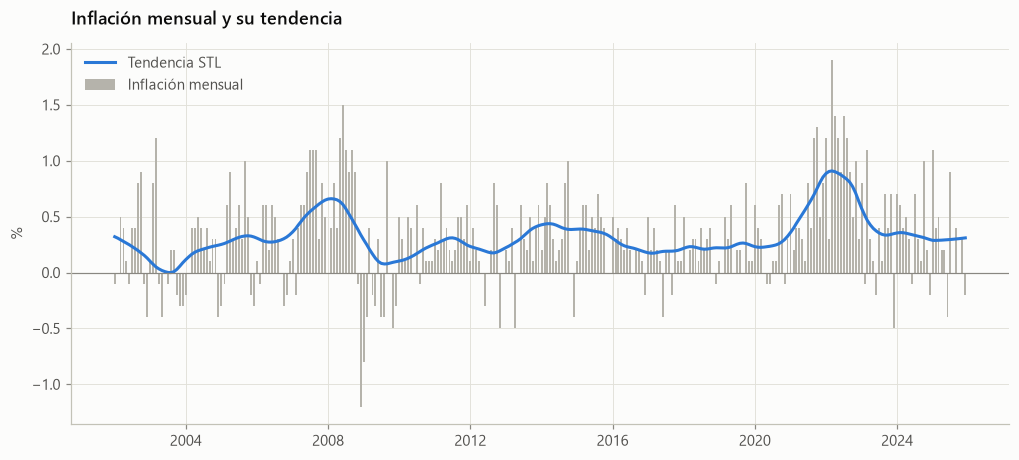

In [4]:
mensual = ipc.loc["2002":].asfreq("MS")
stl = STL(mensual, period=12, robust=True).fit()

fuerza_estacional = max(0, 1 - stl.resid.var() / (stl.resid + stl.seasonal).var())
print(f"Fuerza de la estacionalidad: {fuerza_estacional:.2f} en una escala de 0 a 1")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(mensual.index, mensual, width=20, color=NEUTRO, label="Inflación mensual")
ax.plot(stl.trend.index, stl.trend, color=COLORES[0], linewidth=2, label="Tendencia STL")
ax.axhline(0, color=TINTA_TENUE, linewidth=0.8)
ax.set_ylabel("%")
ax.set_title("Inflación mensual y su tendencia")
ax.legend(loc="upper left")
plt.show()

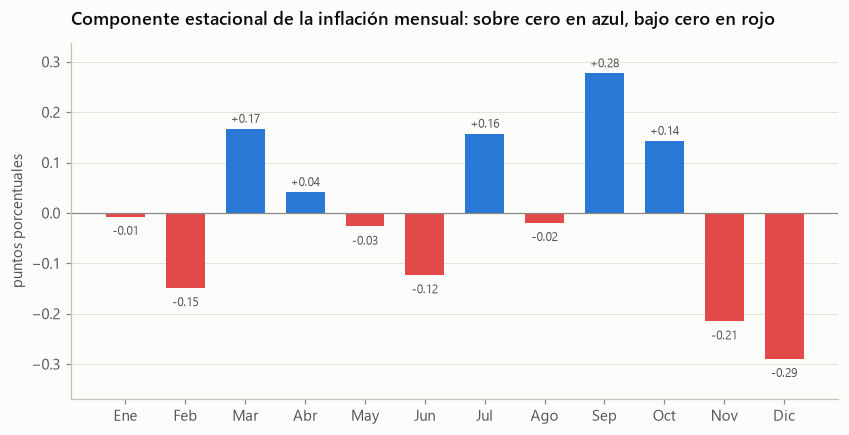

In [5]:
MESES = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
factor = stl.seasonal.groupby(stl.seasonal.index.month).mean()

fig, ax = plt.subplots(figsize=(9, 4.2))
colores = [COLORES[0] if v >= 0 else COLORES[7] for v in factor]
ax.bar(MESES, factor, color=colores, width=0.65)
ax.axhline(0, color=TINTA_TENUE, linewidth=0.8)
for i, v in enumerate(factor):
    ax.annotate(f"{v:+.2f}", (i, v), xytext=(0, 4 if v >= 0 else -12), textcoords="offset points",
                ha="center", fontsize=8, color=TINTA_SECUNDARIA)
ax.set_ylim(factor.min() - 0.08, factor.max() + 0.06)
ax.set_ylabel("puntos porcentuales")
ax.set_title("Componente estacional de la inflación mensual: sobre cero en azul, bajo cero en rojo")
ax.grid(axis="x", visible=False)
fig.savefig(FIGURAS / "estacionalidad_ipc.png", bbox_inches="tight")
plt.show()

**Lectura.** Los meses con inflación sobre lo normal son marzo, julio, septiembre y octubre. Marzo coincide con el inicio del año escolar y el cobro de matrículas. Noviembre y diciembre son los meses más bajos, en línea con las temporadas de descuentos. Atribuir cada mes a una causa exacta requeriría analizar las divisiones del IPC, que esta fuente no publica.

La fuerza estacional es moderada, con un valor cercano a 0,4 en una escala de 0 a 1. Aun así, ignorarla produce pronósticos mensuales sesgados según el mes.

## 4. Actividad económica: IMACEC

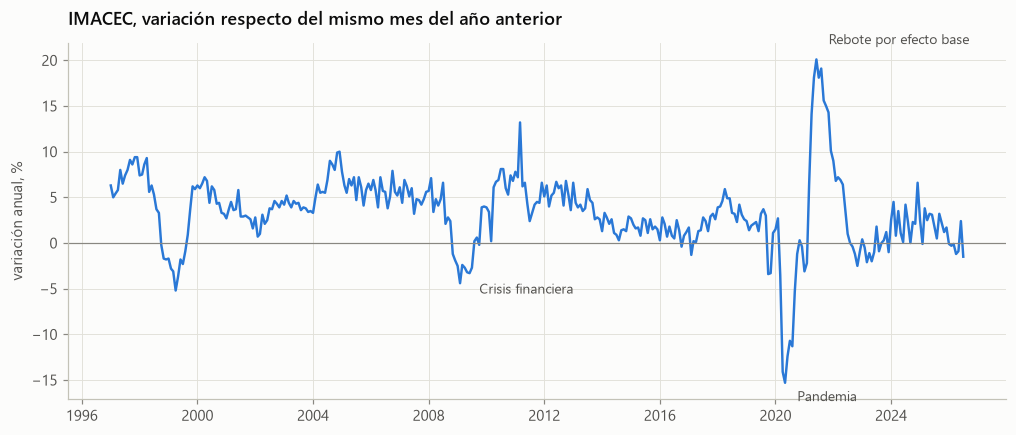

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(imacec.index, imacec, color=COLORES[0])
ax.axhline(0, color=TINTA_TENUE, linewidth=0.8)
for fecha, texto, dy in [("2009-05-01", "Crisis financiera", -14), ("2020-05-01", "Pandemia", -12),
                         ("2021-06-01", "Rebote por efecto base", 10)]:
    f = pd.Timestamp(fecha)
    ax.annotate(texto, (f, imacec.loc[f]), xytext=(8, dy), textcoords="offset points", fontsize=9,
                color=TINTA_SECUNDARIA)
ax.set_ylabel("variación anual, %")
ax.set_title("IMACEC, variación respecto del mismo mes del año anterior")
plt.show()

El IMACEC solo está disponible como variación anual. Esa transformación ya elimina la estacionalidad, pero introduce un efecto base: la caída de 2020 produce un rebote artificial de hasta 20% en 2021, porque se compara contra meses muy deprimidos. Además, cada variación anual comparte once meses con la del mes anterior, lo que genera autocorrelación que los modelos deben considerar. Esto será importante en el VAR del notebook 03.

## 5. ¿Qué series son estacionarias?

Se aplican dos pruebas con hipótesis nulas opuestas. ADF supone raíz unitaria y KPSS supone estacionariedad. Cuando ambas coinciden, la conclusión es sólida.

In [7]:
dolar_mensual = st.a_mensual(dolar, "mean")
candidatas = {
    "log índice IPC": np.log(indice_ipc.loc["2002":]),
    "inflación mensual": ipc.loc["2002":],
    "inflación anual": inflacion_anual.loc["2002":],
    "IMACEC anual": imacec.loc["2002":],
    "TPM fin de mes": st.a_mensual(tpm, "last").loc["2002":],
    "log dólar": np.log(dolar_mensual.loc["2002":]),
    "variación mensual del dólar": 100 * np.log(dolar_mensual).diff().loc["2002":],
}
st.pruebas_raiz_unitaria(candidatas)

,p_adf,p_kpss,conclusion
log índice IPC,0.994,0.010,raíz unitaria
inflación mensual,0.000,0.100,estacionaria
inflación anual,0.036,0.079,estacionaria
IMACEC anual,0.001,0.099,estacionaria
TPM fin de mes,0.008,0.100,estacionaria
log dólar,0.801,0.010,raíz unitaria
variación mensual del dólar,0.000,0.100,estacionaria


**Lectura.**

- **Niveles con raíz unitaria.** El índice de precios y el tipo de cambio no vuelven a un promedio. Se modelan en variaciones.
- **Variaciones estacionarias.** La inflación mensual y anual, el IMACEC anual y la variación del dólar son estacionarias.
- **TPM.** Las pruebas la clasifican como estacionaria, algo esperable porque la política monetaria la devuelve hacia un nivel neutral. En muestras cortas esta conclusión es frágil, así que conviene revisarla con cada actualización de datos.

## 6. Autocorrelación de la inflación mensual

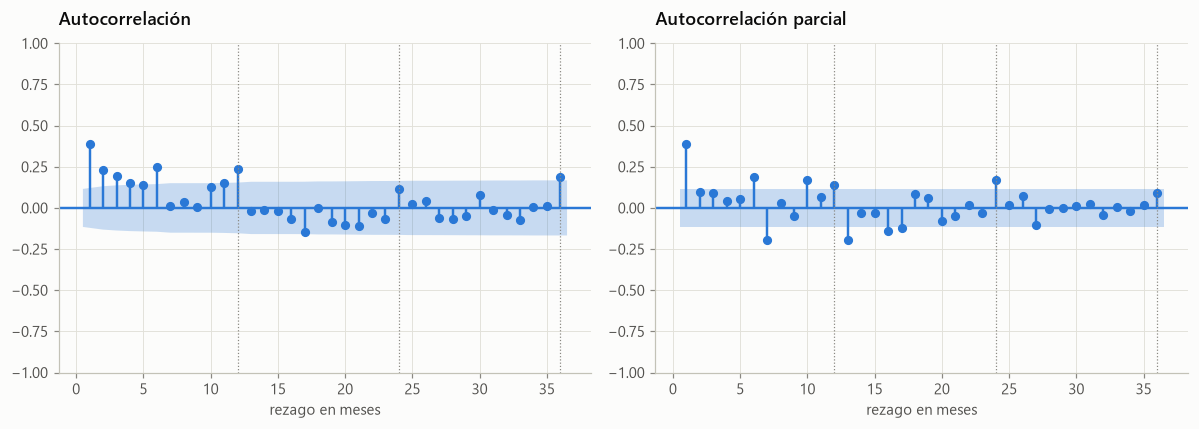

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for funcion, ax, titulo in [(plot_acf, ax1, "Autocorrelación"), (plot_pacf, ax2, "Autocorrelación parcial")]:
    funcion(mensual, lags=36, ax=ax, color=COLORES[0], vlines_kwargs={"colors": COLORES[0]}, zero=False)
    for coleccion in ax.collections:
        if coleccion.__class__.__name__ == "PolyCollection":
            coleccion.set_facecolor(NEUTRO)
            coleccion.set_alpha(0.35)
    ax.set_title(titulo)
    ax.set_xlabel("rezago en meses")
    for rezago in (12, 24, 36):
        ax.axvline(rezago, color=TINTA_TENUE, linewidth=0.8, linestyle=":")
fig.tight_layout()
plt.show()

La autocorrelación del primer rezago indica persistencia de corto plazo. Los picos en los rezagos 12 y 24 confirman la estacionalidad anual. Esta estructura sugiere un modelo SARIMA con componentes no estacionales y estacionales de orden bajo, que se selecciona formalmente en el notebook 02.

## 7. Conclusiones

1. **La inflación chilena tiene estacionalidad moderada y estable.** Un modelo mensual debe incluir un componente estacional de 12 meses.
2. **Los niveles de precios y del dólar se modelan en variaciones.** Las pruebas ADF y KPSS coinciden en que tienen raíz unitaria.
3. **Las variaciones anuales traen costos.** Eliminan la estacionalidad, pero generan efectos base y autocorrelación mecánica que un modelo con pocos rezagos no captura.
4. **La muestra incluye quiebres importantes.** La crisis de 2008, la pandemia y el shock inflacionario de 2021 y 2022 dominan cualquier medida de error. Por eso los notebooks siguientes evalúan los modelos con y sin ese período.